# 2.2 Stations, but now with relocations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from types import SimpleNamespace
import time

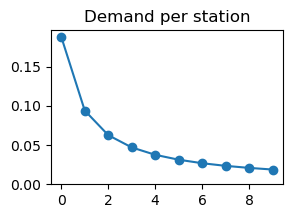

In [2]:
def update_config(cfg):
    # To interpret our data financially, renormalize them to typical daily values for real cities
    # cfg.cm1_factor = 20*5/max(cfg.demand) # Assume 20 trips/day from the hottest zone, and 5 €/trip CM1
    cfg.time_factor = 100/sum(cfg.demand)  # Let's insist on 100 rentals a day, to be able to directly compare different demand shapes
    cfg.cm1_factor = 5  # CM1 contribution per trip, Eur
    cfg.cm2_factor = 20  # CM2 cost of a car per day, Eur
    cfg.relo_cost = 20  # Relo cost per trip
    return cfg

def get_config(scenario, **kwargs):
    """Return a config of values as a SimpleNamespace."""
    d = {}
    d['n_stations'] = 10
    d['n_cars'] = 10
    d['relo_period'] = 50

    d['n_steps_preparation'] = 20000 # For how many steps stats are NOT collected
    d['n_steps_per_experiment'] = 5000
    d['n_experiments'] = 100
    d['start_condition'] = "uniform"

    out = SimpleNamespace(**d)

    # Now set any manual corrections, if any.
    # Warning: as we're doing it here, all properties that are set afterwards are not settable via get_config(key=value) interface.
    # It's not a good design, but also this is just a notebook, not a package.
    for key, value in kwargs.items():
        setattr(out, key, value)

    # Calculate demand
    if scenario == 'linear':
        out.demand = np.arange(out.n_stations, 0, -1)
    elif scenario == 'dropoff':
        out.demand = np.array([1/(1 + i) for i in range(out.n_stations)])  # Drop-off
    elif scenario == 'steps':
        out.demand = np.zeros(out.n_stations)
        n_steps = 3
        n_within = out.n_stations // n_steps
        for i in range(n_steps):
            j = i*n_within
            out.demand[j:min(j+n_within, out.n_stations)] = n_steps - i - 1
    elif scenario == 'cosine':
        out.demand = np.array([np.cos(i/(out.n_stations-1)*np.pi) + 1.2 for i in range(out.n_stations)])  # Hat

    out.demand = out.demand / out.demand.sum()  # First take
    out.demand = np.maximum(out.demand, 0.01)  # Sanitation
    out.demand = out.demand / out.demand.sum() * 0.55  # Final take (the magic number makes the top demand close to 0.1)
    # We need to keep these values low enough, for our binomial process to represent a Poisson process well enough.
    # The actual scaling factor doesn't matter much for CM2 calculations, as we set the CM1 coefficient manually anyways (below)
    # The only two things that matter here are that 1) the shape of the distribution is correct,
    # 2) the values are small enough to resemble Poisson process

    out = update_config(out)
    return out

# Practical test
cfg = get_config('dropoff', n_stations=10)

plt.figure(figsize=(3, 2)) # Visualize demand, to be sure
plt.plot(cfg.demand, 'o-')
plt.ylim(0, None)
plt.title("Demand per station");

In [3]:
def run_model(cfg, seed=None):
    """Main modeling loop as a method"""
    if seed is None:
        seed = int(time.time() * 1000000) % 2**32
    np.random.seed(seed)

    # Make copies of some variables for brevity reasons
    n_steps = cfg.n_steps_preparation + cfg.n_steps_per_experiment*cfg.n_experiments
    n_stations = cfg.n_stations
    demand = cfg.demand

    cm1 = np.zeros(shape=(cfg.n_experiments, n_stations))
    average_cars = np.zeros(shape=(cfg.n_experiments, n_stations))
    total_attempts = np.zeros(shape=(cfg.n_experiments, n_stations))
    total_rentals = np.zeros(shape=(cfg.n_experiments, n_stations))
    total_relos = np.zeros(shape=(cfg.n_experiments, n_stations))

    # "state" is a simple vector listing the number of cars at each station.
    # In this model we don't really trace individual cars (yet).

    if cfg.start_condition == "uniform":
        state = np.array([cfg.n_cars // cfg.n_stations]*n_stations) # Case of cars being distributed uniformly
        state[0] = state[0] + (cfg.n_cars - sum(state))  # Correction in case division failed us
    elif cfg.start_condition == "hot":
        state = np.array([cfg.n_cars] + [0]*(n_stations-1)) # Case of all cars injected in the hot tile
    else:
        raise("Unrecognize starting condition")
    state[0] = cfg.n_cars - state[1:].sum() # Make sure the total n_cars is right (fix rounding errors, if any)
    state_history = np.zeros(shape=(cfg.n_steps_per_experiment, n_stations)) # Will only remember one run

    for i_step in range(n_steps):
        attempts = (np.random.uniform(size=cfg.n_stations) < demand) # If a car was ordered
        departures = attempts * (state > 0)
        destinations = np.random.choice(
            n_stations, size=n_stations, p=demand/sum(demand)) # Where a car would go if ordered
        # The formula above assumes that ultimately in and out flows for every station are balanced, so if
        # few people depart from the station (low demand), it will also be unlikely to become a destination
        # (that's why normalized demand is used as a probability parameter for random.choice)

        if (i_step >= cfg.n_steps_preparation) & ((i_step - cfg.n_steps_preparation) % cfg.n_steps_per_experiment == 0):
            i_experiment = (i_step - cfg.n_steps_preparation) // cfg.n_steps_per_experiment
            print('.', end='') # Experiment counter

        destinations[~departures] = -1 # If the car didn't leave then it doesn't arrive anywhere
        arrivals = [sum(destinations==i) for i in range(n_stations)] # Manual pivot table

        state = state - departures + arrivals

        # Relocations!
        if (cfg.relo_period != 0) and (i_step % cfg.relo_period == 0): # It's time to relocate
            demand_per_car = demand / state.clip(1, None)
            # Starting point: smallest demand per car, and there's a car in this zone
            start_relo = np.where((demand_per_car == demand_per_car[state>0].min()) & (state > 0))[0][0]
            # Ending point: highest demand per car
            end_relo = np.argmax(demand/(1+state.clip(1, None)))
            state[start_relo] -= 1
            state[end_relo] += 1
            relo_happened = True
        else:
            relo_happened = False

        if i_step > cfg.n_steps_preparation: # Collect stats
            # CM1 is first shared between target andd destination, then turned from raw numbers to probabilities,
            # then  from probabilities to daily rates using time-factor, then to daily money using money factor
            cm1[i_experiment, :] += (departures + arrivals)/2/cfg.n_steps_per_experiment * cfg.time_factor * cfg.cm1_factor
            average_cars[i_experiment, :] += state/cfg.n_steps_per_experiment  # Average n cars over time
            total_attempts[i_experiment, :] += attempts*1
            total_rentals[i_experiment, :] += departures
            if relo_happened:
                total_relos[i_experiment, start_relo] += 1

            if (n_steps - i_step) < cfg.n_steps_per_experiment: # Last run
                state_history[(i_step - cfg.n_steps_preparation) % cfg.n_steps_per_experiment, :] = state

    return SimpleNamespace(
            cm1=cm1, average_cars=average_cars, n_apps=total_attempts, n_rentals=total_rentals, n_relos=total_relos, history=state_history
        )

print("Loaded")

Loaded


In [16]:
# CM1 and CM2

def flatten_outputs(out, cfg):
    """Flattens outputs in-place."""
    out.flat_demand = out.n_apps.flatten()/cfg.n_steps_per_experiment *cfg.time_factor # Daily
    out.flat_dfr = out.n_rentals.flatten()/out.n_apps.flatten().clip(1,None)
    out.flat_cm1 = out.cm1.flatten()
    out.flat_cm2 = out.flat_cm1 - out.average_cars.flatten()*cfg.cm2_factor
    return None

def relo_effect_pic(out, cfg, title):
    alpha = 0.08
    plt.figure(figsize=(10.5, 3.5));

    plt.subplot(131)
    plt.title(title, loc='left', pad=15)
    plt.plot(out.n_apps.flatten()/cfg.n_steps_per_experiment * cfg.time_factor,
         out.average_cars.flatten(), '.', alpha=alpha, markersize=10)
    plt.plot(cfg.demand*cfg.time_factor, out.average_cars.mean(axis=0), 'ks-')
    plt.xlabel("Daily demand")
    plt.ylabel("Average number of cars");

    plt.subplot(132)
    plt.plot(out.flat_demand, out.flat_cm1, '.', alpha=alpha, markersize=10)
    plt.plot(out.n_apps.mean(axis=0)/cfg.n_steps_per_experiment*cfg.time_factor, out.cm1.mean(axis=0), 'ks-')
    plt.xlabel("Daily demand")
    plt.ylabel("CM1 per day, Eur");

    plt.subplot(133)
    plt.axhline(0, color='red', linestyle=':')
    plt.plot(out.flat_demand, out.flat_cm2, '.', alpha=alpha, markersize=10)
    plt.plot(
        out.n_apps.mean(axis=0)/cfg.n_steps_per_experiment*cfg.time_factor,
        (out.cm1 - out.average_cars*cfg.cm2_factor).mean(axis=0), 'ks-')
    plt.xlabel("Daily demand")
    plt.ylabel("CM2 per day, Eur");

    plt.tight_layout()
    print()
    print(f"Average rentals per relo: {out.n_rentals.sum()/max(1, out.n_relos.sum())}")
    print(f"Average CM2/day: {out.flat_cm2.sum()/cfg.n_experiments}")

print("Loaded")

Loaded


Settings:  namespace(n_stations=10, n_cars=20, relo_period=1000000000.0, n_steps_preparation=30000, n_steps_per_experiment=5000, n_experiments=100, start_condition='uniform', n_steps_er_experiment=7000, demand=array([0.1 , 0.09, 0.08, 0.07, 0.06, 0.05, 0.04, 0.03, 0.02, 0.01]), time_factor=np.float64(181.8181818181818), cm1_factor=5, cm2_factor=20, relo_cost=20)
....................................................................................................
Average rentals per relo: 191813.0
Average CM2/day: -51.24829090907366


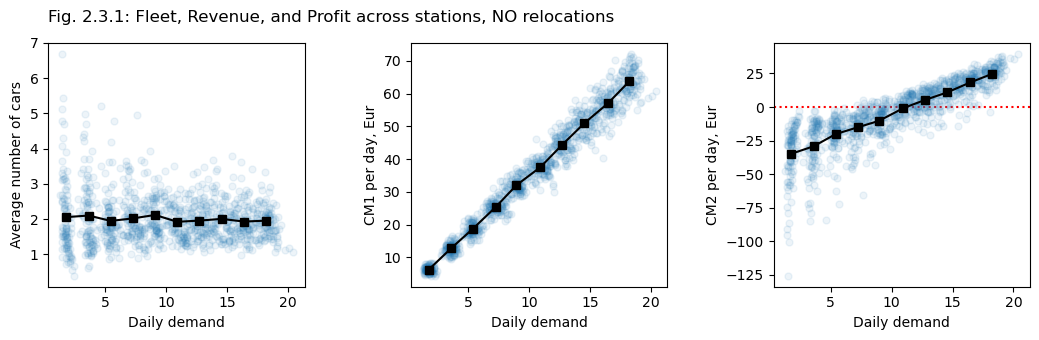

In [18]:
# Experiment 1 : Stations, no relos
cfg = get_config('linear', relo_period=1e9, n_stations=10, n_cars=20, n_steps_preparation=30000, n_steps_er_experiment=7000)
# 1e9 for relo period is basically infinity
print("Settings: ", cfg)
out = run_model(cfg)
flatten_outputs(out, cfg)
relo_effect_pic(out, cfg, title="Fig. 2.3.1: Fleet, Revenue, and Profit across stations, NO relocations")
plt.savefig(f"../figures/02relos_03stations_01norelos.svg", dpi=300)

Settings:  namespace(n_stations=10, n_cars=20, relo_period=30, n_steps_preparation=30000, n_steps_per_experiment=5000, n_experiments=100, start_condition='uniform', n_steps_er_experiment=7000, demand=array([0.1 , 0.09, 0.08, 0.07, 0.06, 0.05, 0.04, 0.03, 0.02, 0.01]), time_factor=np.float64(181.8181818181818), cm1_factor=5, cm2_factor=20, relo_cost=20)
....................................................................................................
Average rentals per relo: 13.266710668426738
Average CM2/day: 2.006254545477239


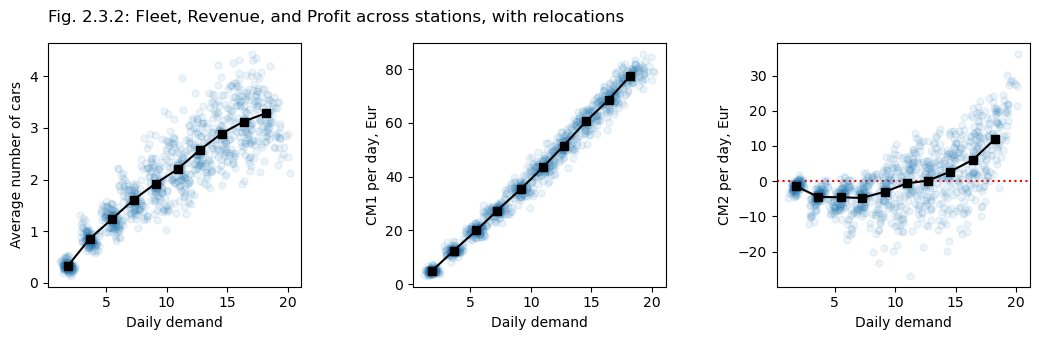

In [19]:
# Experiment 2: Same, but now with relocations
cfg2 = get_config('linear', relo_period=30, n_stations=10, n_cars=20, n_steps_preparation=30000, n_steps_er_experiment=7000)
print("Settings: ", cfg2)
out2 = run_model(cfg2)
flatten_outputs(out2, cfg2)
relo_effect_pic(out2, cfg2, title="Fig. 2.3.2: Fleet, Revenue, and Profit across stations, with relocations")
plt.savefig(f"../figures/02relos_03stations_02relos.svg", dpi=300)

In [20]:
print("DFR without relos: ", out.n_rentals.sum()/out.n_apps.sum()*100)
print("DFR with relos: ", out2.n_rentals.sum()/out2.n_apps.sum()*100)

DFR without relos:  69.77174763108597
DFR with relos:  80.2371154223006


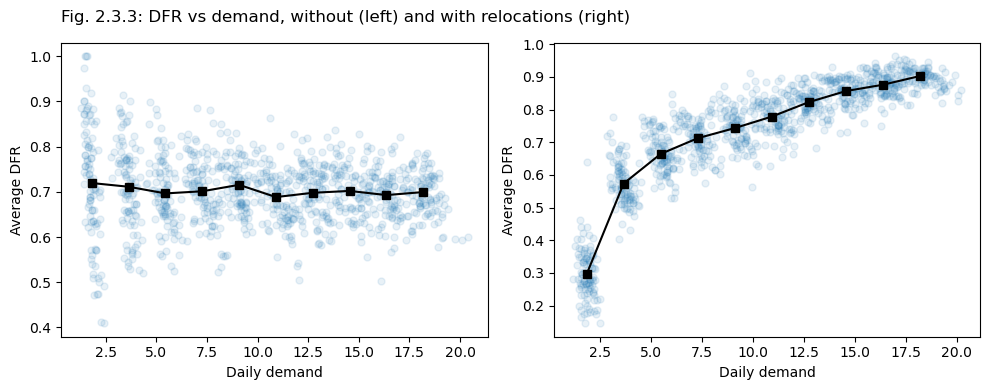

In [24]:
# DFR

def dfr_plot(out):
    plt.plot(out.flat_demand, out.flat_dfr, '.', alpha=0.1, markersize=10)
    plt.plot(cfg.demand * cfg.time_factor, (out.n_rentals/out.n_apps.clip(1,None)).mean(axis=0), 'ks-')
    plt.xlabel("Daily demand")
    plt.ylabel("Average DFR");


plt.figure(figsize=(10,4));
plt.subplot(121)
plt.title("Fig. 2.3.3: DFR vs demand, without (left) and with relocations (right)", loc='left', pad=15)
dfr_plot(out)

plt.subplot(122)
dfr_plot(out2)

plt.tight_layout()

plt.savefig(f"../figures/02relos_03stations_03dfr.svg", dpi=300)

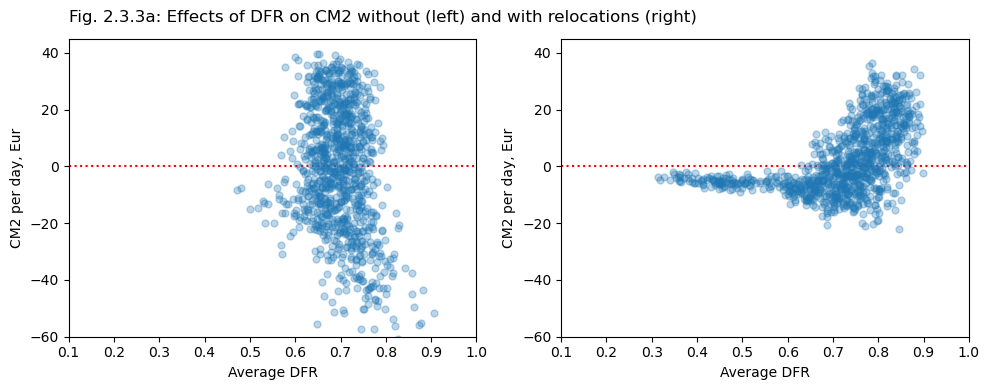

In [340]:
# DFR fancy plot, don't save

plt.figure(figsize=(10,4));
plt.subplot(121)
plt.title("Fig. 2.3.3a: Effects of DFR on CM2 without (left) and with relocations (right)", loc='left', pad=12)
plt.axhline(0, color='red', linestyle=':')
plt.plot(out.flat_dfr, out.flat_cm2, '.', alpha=0.3, markersize=10)
plt.xlabel("Average DFR")
plt.ylabel("CM2 per day, Eur");
plt.xlim([0.1, 1])
plt.ylim([-60, 45])

plt.subplot(122)
plt.axhline(0, color='red', linestyle=':')
plt.plot(out2.flat_dfr, out2.flat_cm2, '.', alpha=0.3, markersize=10)
plt.xlabel("Average DFR")
plt.ylabel("CM2 per day, Eur");
plt.xlim([0.1, 1])
plt.ylim([-60, 45])

plt.tight_layout()

# Optimal number of relocations

* say a zone has a rental probability of `p` (cfg.demand)
* then across `N` time ticks we can expect it to have `Np` rentals
* we actually want our highest zone have 20 rentals
* so with N ticks we essentially modeled `nd = Np/20` days
* the CM1 per day in this case will be equal to `n_rentals/n_days*5 = n_rentals*(5*20/Np) = (n_rentals/N)*(5*20/p)`

Now with relocations.
* Say we had a total of n_relos relocations.
* Relocation rate per day `= n_relos/n_days = n_relos*(20/Np) = (n_relos/N)*(20/p)`
* Relocation cost per day `= 20*(n_relos/N)*(20/p)`

In [ ]:
# Optimal number of relocations
# (Make sure to load a correct scenario before running this one)

scenario = "linear"  # Reasonable options: linear, steps, dropoff
n_experiments = 10
n_steps_per_experiment = 50000

relos_per_10k_ticks = [1, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200]
relocation_periods = [int(10000/k) for k in relos_per_10k_ticks]
print("Relocation periods:", relocation_periods)

relo_cost = 20

cm2_memory = np.zeros(shape=(n_experiments, len(relocation_periods)))

for i, rpr in enumerate(relocation_periods):
    print(f"Relo period {rpr}...")
    cfg = get_config(scenario, relo_period=rpr, n_stations=10, n_cars=15,
                     n_experiments=n_experiments, n_steps_per_experiment=n_steps_per_experiment)
    out = run_model(cfg)
    print("Total relos performed: ", out.n_relos.sum(axis=1))

    # Total CM2 per experiment
    cm2 = out.cm1.sum(axis=1) - cfg.n_cars*cfg.cm2_factor
    # As we are calculating CM2 per day, and our tick value is not set before hand, but is rather
    # re-scaled to achieve a certan value of rental_attempts/day, we now have to
    # re-scale relocation frequency using the same proportionality factor
    relo_expenses = out.n_relos.sum(axis=1)/cfg.n_steps_per_experiment * cfg.time_factor * relo_cost
    print("cm2 with relos:", cm2 - relo_expenses)

    cm2_memory[:, i] = cm2 - relo_expenses

print("done")

Relocation periods: [10000, 500, 250, 166, 125, 100, 83, 71, 62, 55, 50]
Relo period 10000...
......

Scenario: linaar


KeyError: 'linaar'

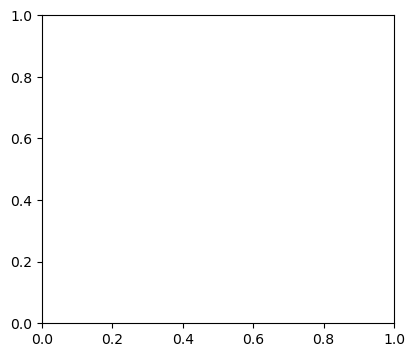

In [ ]:
# Make and save a figure
print(f"Scenario: {scenario}")
plt.figure(figsize=(10,4));
plt.subplot(121)
counter = {"linear":1, "dropoff":2, "steps":3}
plt.title(f"Fig. 2.4.{counter[scenario]}: Optimal relocation frequency for '{scenario}' demand profile", loc='left', pad=12)
# x = total_n_relos/(max(cfg.demand)*n_steps_per_experiment)*20
x = np.array(relos_per_10k_ticks)/10000*n_steps_per_experiment/out.n_rentals.mean()*100
plt.plot(list(x)*n_experiments, cm2_memory.flatten(), '.', color='tab:blue', alpha=0.2,
         label="Individual experiments");
plt.plot(x, cm2_memory.mean(axis=0), 'k.-', label='Average');
plt.xlabel("Relocations per 100 rentals")
plt.ylabel("CM2 per day, Eur\n(including relocation costs)");
# plt.legend(loc="upper right")
plt.legend()

if scenario != "linear":
    default_cfg = get_config("linear")
    plt.subplot(122)
    plt.plot(default_cfg.demand, '.-', color="tab:orange", alpha=0.4, label="Linear demand profile")
    plt.plot(cfg.demand, 'k.-', label="Stepped demand profile")
    plt.xlabel("Station number")
    plt.ylabel("Relative demand per station")
    plt.legend()

plt.tight_layout()

file_name = f"../figures/02relos_04optimal_01{scenario}.svg"
print(file_name)
# plt.savefig(file_name, dpi=300)

# Side-quest: explicitly optimize the distribution of demands for biggest relo effect

In [ ]:
# Explicitly optimize demand

n_improvements = 200
n_steps_per_experiment = 100000  # Instead of running many single experiments, let's run one mega-long experiment
n_stations = 10
n_cars = 15
reset = True

relocation_periods = [1e9, 50]
print("Relocation periods:", relocation_periods)

cm2_memory = np.zeros(shape=(n_improvements, len(relocation_periods)))
if reset or ("demand" not in dir()):  # We may want to continue optimizing when the loop was interrupted
    demand = get_config("linear").demand  # Best demand so far
demand_attempt = demand  # In the future - new experimental demand
demand_history = np.zeros(shape=(n_improvements, len(demand)))
demand_coeff = demand.sum()  # We'll keep this one constant
last_impact = 0
new_impact = 0
learning_rate = 0.3
sampling_radius = 0.01

def normalize_demand(demand):
    demand = np.maximum(0.001, demand)  # Probabilities need to be non-negative, so threshold from below
    demand = np.sort(demand)[::-1]  # Sort and reverse, to have the values decreasing
    demand = demand/demand.sum()*demand_coeff  # Clamp at the original total demand
    return demand

for i_meta in range(n_improvements):
    for i, rpr in enumerate(relocation_periods):
        # Calculate new demand
        if i==0:
            if i_meta>0:  # We don't update on the first run
                if new_impact > last_impact: # Seems like a good change
                    demand = normalize_demand(demand + (demand_attempt-demand)*learning_rate)
                else:
                    demand = normalize_demand(demand - (demand_attempt-demand)*learning_rate)
                np.random.seed(None)  # Randomize next operation
                demand_attempt = normalize_demand(demand + np.random.randn(len(demand))*sampling_radius)

            demand_history[i_meta, :] = demand

        print(f"demand={str(demand.round(3))} ; relo_period={rpr:.0f}", end=" ")
        cfg = get_config("linear", relo_period=rpr, n_experiments=1, n_steps_per_experiment=n_steps_per_experiment, n_cars=n_cars)
        cfg.demand = demand_attempt
        cfg = update_config(cfg)
        out = run_model(cfg)  # True random (we don't want the demand pattern to repeat)

        cm2 = out.cm1.sum()*cfg.cm1_factor - cfg.n_cars*cfg.cm2_factor
        relo_expenses = out.n_relos.sum()/cfg.n_steps_per_experiment * cfg.relo_cost*(20/max(cfg.demand))
        cm2_memory[i_meta, i] = cm2 - relo_expenses
        print(f" cm2={cm2_memory[i_meta, i]:.3f}")

    last_impact = new_impact
    new_impact = cm2_memory[i_meta,1]-cm2_memory[i_meta,0]
    print(f"Step {i_meta}; improvement of {new_impact:.3f}")

print("done")

Relocation periods: [1000000000.0, 50]
demand=[0.1  0.09 0.08 0.07 0.06 0.05 0.04 0.03 0.02 0.01] ; relo_period=1000000000 . cm2=14.036
demand=[0.1  0.09 0.08 0.07 0.06 0.05 0.04 0.03 0.02 0.01] ; relo_period=50 . cm2=-22.524
Step 0; improvement of -36.560
demand=[0.1  0.09 0.08 0.07 0.06 0.05 0.04 0.03 0.02 0.01] ; relo_period=1000000000 . cm2=15.391
demand=[0.1  0.09 0.08 0.07 0.06 0.05 0.04 0.03 0.02 0.01] ; relo_period=50 . cm2=-27.935
Step 1; improvement of -43.326
demand=[0.102 0.09  0.079 0.067 0.063 0.05  0.038 0.028 0.023 0.011] ; relo_period=1000000000 . cm2=11.918
demand=[0.102 0.09  0.079 0.067 0.063 0.05  0.038 0.028 0.023 0.011] ; relo_period=50 . cm2=-33.061
Step 2; improvement of -44.980
demand=[0.104 0.091 0.08  0.065 0.063 0.052 0.037 0.025 0.023 0.011] ; relo_period=1000000000 . cm2=16.373
demand=[0.104 0.091 0.08  0.065 0.063 0.052 0.037 0.025 0.023 0.011] ; relo_period=50 . cm2=-30.411
Step 3; improvement of -46.784
demand=[0.108 0.09  0.078 0.062 0.061 0.053 0.039

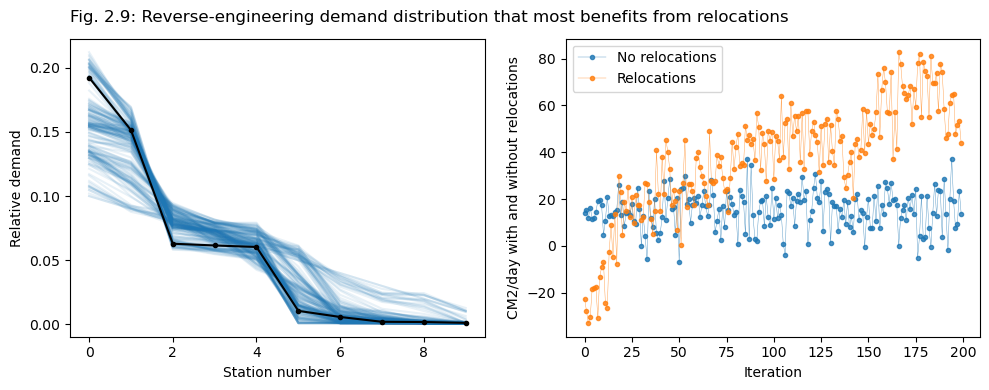

In [29]:
plt.figure(figsize=(10,4))
plt.subplot(121)
plt.title("Fig. 2.9: Reverse-engineering demand distribution that most benefits from relocations", loc='left', pad=12)
plt.plot(np.arange(len(demand)), demand_history.T, color='tab:blue', alpha=0.1)
plt.plot(demand, 'k.-')
plt.xlabel("Station number")
plt.ylabel("Relative demand")

plt.subplot(122)
plt.plot(np.arange(cm2_memory.shape[0]), cm2_memory[:,0], '.-', color='tab:blue', alpha=0.8, label="No relocations", linewidth=0.3)
plt.plot(np.arange(cm2_memory.shape[0]), cm2_memory[:,1], '.-', color='tab:orange', alpha=0.8, label="Relocations", linewidth=0.3)
# plt.plot(np.arange(cm2_memory.shape[0]), cm2_memory, 'k.')
plt.legend()
plt.xlabel("Iteration")
plt.ylabel("CM2/day with and without relocations");

plt.tight_layout()
# plt.savefig(f"../figures/02relos_04optimal_05search.svg", dpi=300)